In [36]:
%load_ext autoreload
%autoreload 2
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from codebase.src.GWAS.GWAS import GWAS 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
phenotype = pd.read_csv("../data/phenotype/phenotype_matrix.csv", index_col=0)
phenotype.head()

,HEA,TGW,HEI,RIP,PM
Genotype,,,,,
HEB_01_001,62.0,53.63,53.0,35.0,7.0
HEB_01_003,67.0,57.62,58.0,34.0,5.0
HEB_01_004,57.0,52.15,74.0,40.0,1.0
HEB_01_005,69.0,54.16,60.0,34.0,6.0
HEB_01_013,64.0,51.40,60.0,34.0,1.0


In [38]:
genotype = pd.read_csv("../data/genotype/genotype_matrix_knn.csv", index_col=0)
genotype.head()

,SCRI_RS_136200,SCRI_RS_156845,SCRI_RS_133377,SCRI_RS_190048,BOPA2_12_31497,SCRI_RS_141771,SCRI_RS_209516,BOPA2_12_31284,SCRI_RS_185319,SCRI_RS_198643,...,SCRI_RS_174077,SCRI_RS_194653,SCRI_RS_116590,SCRI_RS_172136,SCRI_RS_73620,SCRI_RS_170209,SCRI_RS_139106,SCRI_RS_139115,SCRI_RS_142982,SCRI_RS_139737
Genotype,,,,,,,,,,,,,,,,,,,,,
HEB_01_001,2,2.0,2,2,2,2,2,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
HEB_01_003,2,2.0,2,2,2,2,2,1,2,2,...,0,0.0,0,0,0,0,0,0,0,0
HEB_01_004,2,2.0,2,2,2,2,2,0,0,0,...,1,1.0,1,1,1,1,2,2,2,2
HEB_01_005,2,2.0,2,2,2,2,2,1,1,1,...,0,0.0,0,0,0,0,0,0,0,0
HEB_01_013,2,2.0,2,2,2,2,2,2,2,2,...,2,2.0,2,2,2,2,2,2,2,2


In [39]:
locations = pd.read_csv("../data/genotype/genotype_location.csv", index_col=0)
locations

,Chr,Pos
Marker,,
SCRI_RS_136200,2,2.3
SCRI_RS_156845,2,4.0
SCRI_RS_133377,2,6.3
SCRI_RS_190048,2,6.3
BOPA2_12_31497,2,8.6
...,...,...
SCRI_RS_170209,2,144.4
SCRI_RS_139106,2,146.4
SCRI_RS_139115,2,146.4


In [40]:
gwas = GWAS()

In [ ]:
#
# cautious: actual phenotype and it name, must match !!! 
#
result = gwas.quantitative(
    phenotype=phenotype.HEA,
    genotype=genotype,
    positions=locations,
    export=True,
    phenotype_name = "HEA"
)

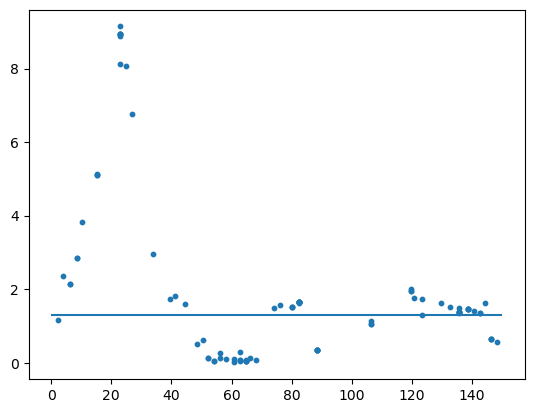

In [42]:
plt.scatter(result["Pos"], -np.log10(result["p-value"]), s=10)
plt.hlines(y=1.3,xmin=0, xmax=150)

In [44]:
with pd.option_context('display.max_rows', 100, 'display.max_columns', 100):
    display(result.sort_values(by=["r-value"], ascending=False))

,Marker,Chr,Pos,slope,p-value,r-value
13,BK_16,2,23.0,4.202381,7.120673e-10,0.525558
11,BK_14,2,23.0,4.157158,1.165179e-09,0.519877
14,BOPA2_12_30871,2,23.0,4.157158,1.165179e-09,0.519877
10,BK_12,2,23.0,4.157158,1.165179e-09,0.519877
15,BOPA2_12_30872,2,23.0,4.157158,1.165179e-09,0.519877
12,BK_15,2,23.0,4.151169,1.310043e-09,0.518509
16,SCRI_RS_170337,2,23.0,4.130993,7.492436e-09,0.497412
17,SCRI_RS_155612,2,24.8,4.174373,8.660527e-09,0.495593
18,BOPA1_7032_201,2,26.8,3.730721,1.751540e-07,0.455232
7,BOPA2_12_31284,2,15.4,3.250000,7.288847e-06,0.396656
